In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io.shapereader import Reader
import warnings
warnings.filterwarnings('ignore')

# ==================== Global path configuration ====================
INFO_PATH = "./typhoon_output/landfall_typhoons_info.csv"
TRACKS_PATH = "./typhoon_output/landfall_typhoons_tracks.csv"
MJO_PATH = "./ERA5 MJO (1950-2024).csv"
CHINA_SHP = "./shapefiles/china.shp"
NINE_LINE_SHP = "./shapefiles/china_nine_dotted_line.shp"

 

# ==================== MJO phase filtering function ====================
def phase_to_group(phase):
    """Used for filtering only; no grouping needed here, keeping function for expansion"""
    if pd.isna(phase):
        return None
    p = int(phase)
    if p in [1, 2]:
        return 'Phases 1-2'
    elif p in [3, 4]:
        return 'Phases 3-4'
    elif p in [5, 6]:
        return 'Phases 5-6'
    elif p in [7, 8]:
        return 'Phases 7-8'
    else:
        return None

# ==================== Region division function ====================
def region_from_lat(lat):
    """Return region name based on landfall latitude"""
    if lat < 24:
        return 'South China'
    elif lat <= 34:
        return 'East China'
    else:
        return 'North China'

REGIONS = ['South China', 'East China', 'North China']

# ==================== 1. Load and filter typhoon landfall information ====================
print("Loading typhoon landfall information...")
info_df = pd.read_csv(INFO_PATH)
info_df['code_str'] = info_df['chinese_code'].apply(lambda x: f"{x:04d}")
info_df['landfall_time'] = pd.to_datetime(info_df['landfall_time'])
info_df['landfall_date'] = info_df['landfall_time'].dt.date
info_df['year'] = info_df['landfall_time'].dt.year
info_df['month'] = info_df['landfall_time'].dt.month

# Filter: 1960–2024, June–October
mask = (info_df['year'] >= 1960) & (info_df['year'] <= 2024) & (info_df['month'].between(6, 10))
info_df = info_df[mask].copy()
print(f"Number of landfall events meeting time criteria: {len(info_df)}")

# Keep necessary fields, use max_wind_category for typhoon intensity classification
info_clean = info_df[['code_str', 'name', 'landfall_date', 'landfall_lat', 'landfall_lon',
                      'max_wind_category']].copy()
info_clean.rename(columns={'max_wind_category': 'typhoon_category'}, inplace=True)

# ==================== 2. Load and filter MJO data (keep only amplitude ≥1) ====================
print("Loading MJO data...")
mjo_df = pd.read_csv(MJO_PATH)
mjo_df['date'] = pd.to_datetime(mjo_df['date']).dt.date

# Time range 1960–2024
mjo_df = mjo_df[(mjo_df['date'] >= pd.to_datetime('1960-01-01').date()) &
                (mjo_df['date'] <= pd.to_datetime('2024-12-31').date())]

# Keep only active events with amplitude ≥1
mjo_df = mjo_df[mjo_df['amplitude'] >= 1].copy()
print(f"Number of MJO active day records: {len(mjo_df)}")

# Build date -> active boolean dictionary (only for filtering, not concerned with specific phase)
active_dates = set(mjo_df['date'].values)

# ==================== 3. Match landfall dates with MJO ====================
info_clean['mjo_active'] = info_clean['landfall_date'].isin(active_dates)
info_clean = info_clean[info_clean['mjo_active']].copy()
print(f"Number of landfall events matched with MJO active days: {len(info_clean)}")

# Add region column
info_clean['region'] = info_clean['landfall_lat'].apply(region_from_lat)

# View event counts by region
print("\nLandfall event counts by region (MJO active days):")
print(info_clean['region'].value_counts())

# ==================== 4. Extract typhoon genesis positions ====================
print("Extracting typhoon genesis positions...")
tracks_df = pd.read_csv(TRACKS_PATH)
tracks_df['TIME'] = pd.to_datetime(tracks_df['TIME'])
tracks_df['code_str'] = tracks_df['chinese_code'].apply(lambda x: f"{x:04d}")

# Group by typhoon code, take the earliest time row as the genesis point
start_points = tracks_df.sort_values('TIME').groupby('code_str').first().reset_index()
start_points = start_points[['code_str', 'LAT', 'LONG']].rename(columns={'LAT': 'start_lat', 'LONG': 'start_lon'})
print(f"Successfully extracted {len(start_points)} typhoon genesis points")

# Merge genesis information into the landfall event table (each landfall event linked to its typhoon's genesis)
info_clean = info_clean.merge(start_points, on='code_str', how='inner')
print(f"Number of landfall events after merging (with genesis info): {len(info_clean)}")

Loading typhoon landfall information...
Number of landfall events meeting time criteria: 464
Loading MJO data...
Number of MJO active day records: 14550
Number of landfall events matched with MJO active days: 258

Landfall event counts by region (MJO active days):
South China    176
East China      67
North China     15
Name: region, dtype: int64
Extracting typhoon genesis positions...
Successfully extracted 490 typhoon genesis points
Number of landfall events after merging (with genesis info): 258


China land border loaded successfully
Number of typhoons meeting criteria (landfall & MJO≥1): 258
Number of corresponding landfall events: 258
Final number of typhoons included in analysis (category 1-3 with genesis point): 258

Affected regions for all typhoons:
+----------------+------------+------------+--------------------------------------+
|   Typhoon Code | Name       |   Category | Affected Regions                     |
+================+============+============+======================================+
|              4 | Kai-tak    |          2 | South China, East China, North China |
+----------------+------------+------------+--------------------------------------+
|              8 | Jelawat    |          2 | East China                           |
+----------------+------------+------------+--------------------------------------+
|             10 | Bilis      |          3 | South China, East China              |
+----------------+------------+------------+--------------------

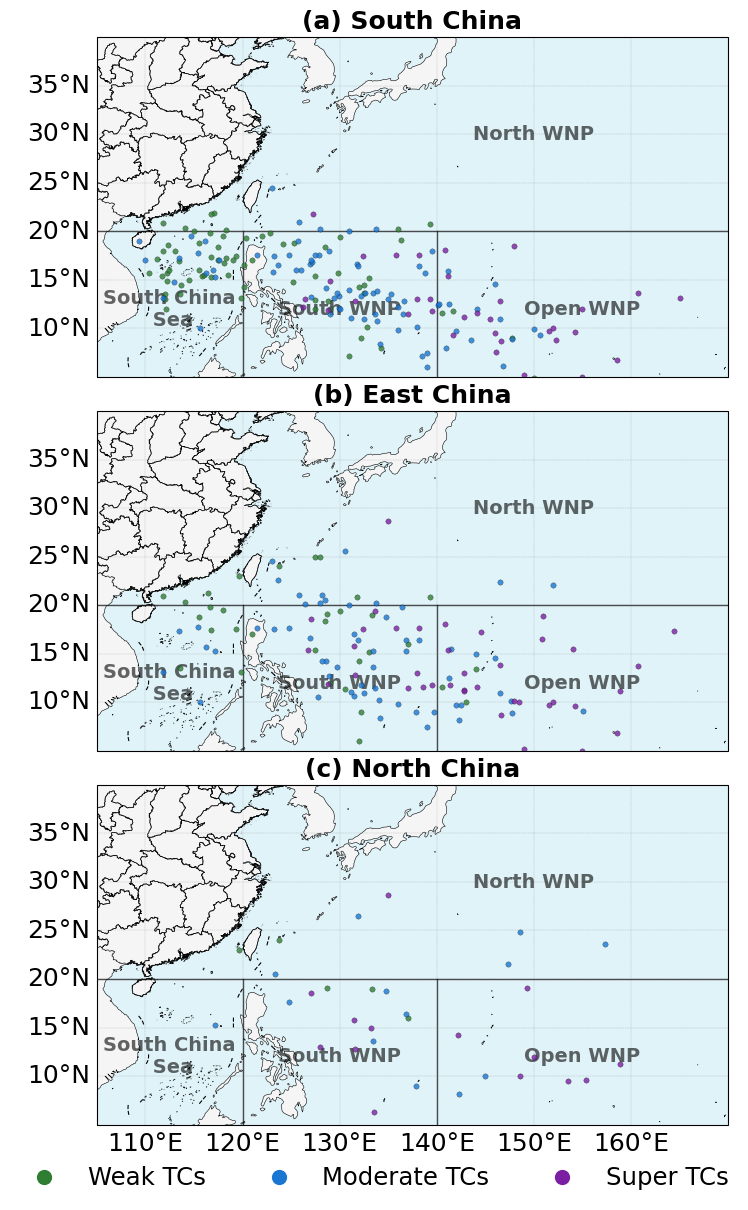

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io.shapereader import Reader
from shapely.geometry import Point
from shapely.ops import unary_union
from tabulate import tabulate
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')




# ## 1. Define helper functions and constants

# %%
# Wind category function (consistent with the given definition)
def get_wind_category(wind_speed):
    """Return category 0,1,2,3 based on wind speed (m/s)"""
    if pd.isna(wind_speed):
        return 0
    if wind_speed <= 17.1:
        return 0
    elif wind_speed <= 32.6:
        return 1
    elif wind_speed < 51.0:
        return 2
    else:
        return 3

# Category names and color mapping (only categories 1-3)
 
category_names  = {1: 'Weak TCs', 2: 'Moderate TCs', 3: 'Super TCs'}
category_colors = {1: '#2E7D32', 2: '#1976D2', 3: '#7B1FA2'}
 

# Coastal region latitude ranges
REGIONS = {
    'South China': (None, 24),        # <24°N
    'East China': (24, 34),           # 24≤lat<34
    'North China': (34, None)         # ≥34°N
}

# File paths
landfall_info_path = './typhoon_output/landfall_typhoons_info.csv'
tracks_path = './typhoon_output/landfall_typhoons_tracks.csv'
mjo_path = './ERA5 MJO (1950-2024).csv'
china_shp = './shapefiles/china.shp'
nine_dash_shp = './shapefiles/china_nine_dotted_line.shp'

# Read China border for land determination
from shapely.geometry import shape
import fiona

def load_china_land():
    """Load China land polygons (including mainland and islands)"""
    land_polys = []
    with fiona.open(china_shp, 'r') as src:
        for feature in src:
            geom = shape(feature['geometry'])
            land_polys.append(geom)
    # Merge all polygons into a single MultiPolygon (or a single polygon)
    return unary_union(land_polys)

china_land = load_china_land()
print("China land border loaded successfully")

# %% [markdown]
# ## 2. Read data

# %%
# Read data
df_landfall = pd.read_csv(landfall_info_path)
df_tracks = pd.read_csv(tracks_path)
df_mjo = pd.read_csv(mjo_path)

# Convert time columns
df_landfall['landfall_time'] = pd.to_datetime(df_landfall['landfall_time'])
df_tracks['TIME'] = pd.to_datetime(df_tracks['TIME'])
df_mjo['date'] = pd.to_datetime(df_mjo['date'])

# %% [markdown]
# ## 3. Filter landfall events: 1960-2024, June-October, and landfall day MJO amplitude ≥1

# %%
# Filter by year and month
df_landfall = df_landfall[(df_landfall['year'] >= 1960) & (df_landfall['year'] <= 2024)]
df_landfall = df_landfall[df_landfall['landfall_time'].dt.month.between(6, 10)]

# Match MJO amplitude to each landfall event (by date)
df_landfall['date'] = df_landfall['landfall_time'].dt.date
df_mjo['date'] = df_mjo['date'].dt.date
df_landfall = df_landfall.merge(df_mjo[['date', 'amplitude']], on='date', how='left')

# Keep events with MJO amplitude ≥1
df_landfall = df_landfall[df_landfall['amplitude'] >= 1].copy()

# Get unique typhoon codes that meet the conditions
valid_typhoons = df_landfall['chinese_code'].unique()
print(f"Number of typhoons meeting criteria (landfall & MJO≥1): {len(valid_typhoons)}")
print(f"Number of corresponding landfall events: {len(df_landfall)}")

# %% [markdown]
# ## 4. Determine the first landfall time for each typhoon

# %%
# Group by typhoon code, take the earliest landfall time as first landfall
first_landfall_time = df_landfall.groupby('chinese_code')['landfall_time'].min().reset_index()
first_landfall_time.columns = ['chinese_code', 'first_landfall_time']

# Merge the latitude of the first landfall (to determine the region of the first landfall)
first_landfall_lat = df_landfall.sort_values('landfall_time').groupby('chinese_code').first()['landfall_lat'].reset_index()
first_landfall_lat.columns = ['chinese_code', 'first_landfall_lat']
first_landfall_info = first_landfall_time.merge(first_landfall_lat, on='chinese_code')


def process_typhoon_tracks(group):
    chinese_code = group['chinese_code'].iloc[0]
    # Extract genesis point (earliest point with valid wind speed)
    group_sorted = group.sort_values('TIME')
    start_idx = group_sorted['WND'].first_valid_index()
    if start_idx is None:
        return None  # No valid wind speed for genesis point
    start_row = group_sorted.loc[start_idx]
    
    # Get the maximum wind speed and category of this typhoon
    max_wind = group['max_wind'].iloc[0]
    category = get_wind_category(max_wind)
    if category not in [1,2,3]:
        return None  # Only keep categories 1-3
    
    # Determine the first landfall time (obtained from first_landfall_info)
    first_time = first_landfall_info.loc[first_landfall_info['chinese_code'] == chinese_code, 'first_landfall_time'].values
    if len(first_time) == 0:
        # This typhoon has no landfall event (theoretically won't happen, as valid_typhoons guarantees a landfall)
        return None
    first_time = first_time[0]
    
    # Region affected by the first landfall (based on first landfall latitude)
    first_lat = first_landfall_info.loc[first_landfall_info['chinese_code'] == chinese_code, 'first_landfall_lat'].values[0]
    regions_affected = set()
    if first_lat < 24:
        regions_affected.add('South China')
    elif first_lat < 34:
        regions_affected.add('East China')
    else:
        regions_affected.add('North China')
    
    # Filter track points after first landfall (time >= first_time)
    post_landfall = group_sorted[group_sorted['TIME'] >= first_time]
    
    # For each post-landfall point, check if it is on China's land
    for _, row in post_landfall.iterrows():
        lon, lat = row['LONG'], row['LAT']
        # Check if the point is on China's land
        point = Point(lon, lat)
        if china_land.contains(point):
            # Determine region by latitude
            if lat < 24:
                regions_affected.add('South China')
            elif lat < 34:
                regions_affected.add('East China')
            else:
                regions_affected.add('North China')
            # If all three regions have been collected, can exit early (but keep all for accuracy)
    
    return pd.Series({
        'chinese_code': chinese_code,
        'name': group['name'].iloc[0],
        'start_lat': start_row['LAT'],
        'start_lon': start_row['LONG'],
        'start_wnd': start_row['WND'],
        'max_wind': max_wind,
        'category': category,
        'regions': list(regions_affected)  # Convert to list
    })


starts = df_tracks.groupby('chinese_code').apply(process_typhoon_tracks).dropna().reset_index(drop=True)
print(f"Final number of typhoons included in analysis (category 1-3 with genesis point): {len(starts)}")


details = []
for idx, row in starts.iterrows():
    details.append({
        'Typhoon Code': row['chinese_code'],
        'Name': row['name'],
        'Category': row['category'],
        'Affected Regions': ', '.join(row['regions'])
    })

print("\nAffected regions for all typhoons:")
print(tabulate(details, headers='keys', tablefmt='grid'))


typhoon_code_array = starts['chinese_code'].tolist()
print(f"\nTyphoon code array (total {len(typhoon_code_array)}):")
print(typhoon_code_array)


region_typhoons = {}
for region in REGIONS.keys():
    mask = starts['regions'].apply(lambda x: region in x)
    region_typhoons[region] = starts[mask].copy()
    print(f"{region}: {len(region_typhoons[region])} typhoons")


def add_china_boundaries(ax):
    """Add China borders (including province boundaries) and the nine-dash line"""
    try:
        china = Reader(china_shp)
        ax.add_geometries(china.geometries(), ccrs.PlateCarree(),
                          facecolor='none', edgecolor='black', linewidth=0.5, alpha=0.8)
    except Exception as e:
        print(f"Failed to load China border file: {e}")
    try:
        nine_line = Reader(nine_dash_shp)
        ax.add_geometries(nine_line.geometries(), ccrs.PlateCarree(),
                          facecolor='none', edgecolor='black', linewidth=0.8, linestyle='--')
    except Exception as e:
        print(f"Failed to load nine-dash line file: {e}")

def setup_map(ax, extent=[105, 170, 5, 40], show_bottom_labels=False):
    """Set up basic map elements; control whether bottom latitude labels are shown"""
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor='black')
    ax.add_feature(cfeature.LAND, facecolor='#F5F5F5')
    ax.add_feature(cfeature.OCEAN, facecolor='#E0F3F8')

    add_china_boundaries(ax)
    

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=0.3, linestyle='--', color='gray', alpha=0.5)
    gl.top_labels = False         
    gl.right_labels = False        
    gl.bottom_labels = show_bottom_labels  
    gl.left_labels = True          
    gl.xlabel_style = {'size': 18}
    gl.ylabel_style = {'size': 18}


fig, axes = plt.subplots(3, 1, figsize=(9, 12.5), sharex=True, sharey=True,
                         subplot_kw={'projection': ccrs.PlateCarree()})


handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=category_colors[cat], markersize=12,
                      label=category_names[cat]) for cat in [1,2,3]]


itit = ["(a) ", "(b) ", "(c) "]
for i, (ax, region_name, it) in enumerate(zip(axes, REGIONS.keys(), itit)):

    show_bottom = (i == len(axes) - 1)
    setup_map(ax, extent=[105, 170, 5, 40], show_bottom_labels=show_bottom)

    df_region = region_typhoons[region_name]
    
    if len(df_region) == 0:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes,
                ha='center', va='center', fontsize=12, color='gray')
    else:

        for cat in [1,2,3]:
            subset = df_region[df_region['category'] == cat]
            if len(subset) == 0:
                continue
            ax.scatter(subset['start_lon'], subset['start_lat'],
                       s=15, c=category_colors[cat],
                       edgecolor='black', linewidth=0.2,
                       alpha=0.8, transform=ccrs.PlateCarree(),
                       zorder=5)

    ax.axhline(y=20, color='black', linewidth=1, linestyle='-', alpha=0.7)
    ax.plot([120, 120], [0, 20], color='black', linewidth=1, linestyle='-',
            alpha=0.7, transform=ccrs.PlateCarree())
    ax.plot([140, 140], [0, 20], color='black', linewidth=1, linestyle='-',
            alpha=0.7, transform=ccrs.PlateCarree())
    

    ax.text(112.5, 12, 'South China\n Sea', transform=ccrs.PlateCarree(), alpha=0.6,
            fontsize=14, ha='center', va='center', color='black', weight='bold')
    ax.text(130, 12, 'South WNP', transform=ccrs.PlateCarree(), alpha=0.6,
            fontsize=14, ha='center', va='center', color='black', weight='bold')
    ax.text(155, 12, 'Open WNP', transform=ccrs.PlateCarree(), alpha=0.6,
            fontsize=14, ha='center', va='center', color='black', weight='bold')
    ax.text(150, 30, 'North WNP', transform=ccrs.PlateCarree(), alpha=0.6,
            fontsize=14, ha='center', va='center', color='black', weight='bold')
    
    ax.set_title(it + region_name, fontsize=18, fontweight='bold')


fig.legend(handles=handles, labels=['Weak TCs', 'Moderate TCs', 'Super TCs'],
           loc='lower center', ncol=3, fontsize=17.5, frameon=False, bbox_to_anchor=(0.47, -0.02))

plt.subplots_adjust(top=0.92, bottom=0.05, hspace=0.1)
plt.savefig('7all.png', dpi=600, bbox_inches='tight')
plt.show()